In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings as wr 
wr.filterwarnings('ignore') 

In [2]:
df = pd.read_csv("D:\The Fly Nest\Python\Python Projects\Company Financials Dataset\Financials.csv")
df

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,"$2,475.00",$260.00,$300.00,"$7,42,500.00","$1,11,375.00","$6,31,125.00","$6,18,750.00","$12,375.00",01/03/2014,3,March,2014
696,Small Business,Mexico,Amarilla,High,$546.00,$260.00,$300.00,"$1,63,800.00","$24,570.00","$1,39,230.00","$1,36,500.00","$2,730.00",01/10/2014,10,October,2014
697,Government,Mexico,Montana,High,"$1,368.00",$5.00,$7.00,"$9,576.00","$1,436.40","$8,139.60","$6,840.00","$1,299.60",01/02/2014,2,February,2014
698,Government,Canada,Paseo,High,$723.00,$10.00,$7.00,"$5,061.00",$759.15,"$4,301.85","$3,615.00",$686.85,01/04/2014,4,April,2014


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

In [4]:
# Clean Column Names (Remove Extra Spaces)

df.columns = df.columns.str.strip()

In [5]:
#Convert Numeric Columns (Remove '$', ',', and Handle Negative Values in Parentheses)
num_cols = [
    "Units Sold", "Manufacturing Price", "Sale Price", "Gross Sales", 
    "Discounts", "Sales", "COGS", "Profit"
]

def clean_currency(value):
    """Convert currency formatted strings to float."""
    if isinstance(value, str):
        value = value.strip().replace("$", "").replace(",", "")
        # Convert (number) to -number
        if re.match(r"\(\d+(\.\d+)?\)", value):
            value = "-" + value.strip("()")
        return float(value) if value not in ["", "-"] else None
    return value

In [6]:
# Apply the function to numeric columns

import re

for col in num_cols:
    df[col] = df[col].apply(clean_currency)

In [7]:
# Handle Missing Values

df["Discount Band"] = df["Discount Band"].replace("None", pd.NA)  

# Convert "None" to NaN

In [8]:
# Convert "Date" Column to Datetime Format

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [9]:
# Display Cleaned Data Summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        700 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    float64       
 6   Sale Price           700 non-null    float64       
 7   Gross Sales          700 non-null    float64       
 8   Discounts            647 non-null    float64       
 9   Sales                700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               695 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

In [10]:
import pandas as pd

# Ensure "Month Name" column has no extra spaces
df["Month Name"] = df["Month Name"].str.strip()

# Define season mapping for Northern Hemisphere (Canada, France, Germany, USA)
season_mapping_north = {
    "January": "Winter", "February": "Winter", "March": "Spring",
    "April": "Spring", "May": "Spring", "June": "Summer",
    "July": "Summer", "August": "Summer", "September": "Autumn",
    "October": "Autumn", "November": "Autumn", "December": "Winter"
}

# Define season mapping for Mexico (Tropical Region)
season_mapping_mexico = {
    "January": "Dry Season", "February": "Dry Season", "March": "Dry Season",
    "April": "Dry Season", "May": "Rainy Season", "June": "Rainy Season",
    "July": "Rainy Season", "August": "Rainy Season", "September": "Rainy Season",
    "October": "Rainy Season", "November": "Dry Season", "December": "Dry Season"
}

# Function to assign seasons based on country
def assign_season(row):
    if row["Country"].strip() == "Mexico":  # Strip spaces to avoid mismatch
        return season_mapping_mexico.get(row["Month Name"], "Unknown")
    else:
        return season_mapping_north.get(row["Month Name"], "Unknown")

# Apply function to create a new "Season" column
df["Season"] = df.apply(assign_season, axis=1)

# Display first few rows to verify
print(df[["Country", "Month Name", "Season"]].head())


   Country Month Name        Season
0   Canada    January        Winter
1  Germany    January        Winter
2   France       June        Summer
3  Germany       June        Summer
4   Mexico       June  Rainy Season


In [11]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,Season
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,NaN,32370.0,16185.0,16185.0,2014-01-01,1,January,2014,Winter
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,NaN,26420.0,13210.0,13210.0,2014-01-01,1,January,2014,Winter
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,NaN,32670.0,21780.0,10890.0,2014-01-06,6,June,2014,Summer
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,NaN,13320.0,8880.0,4440.0,2014-01-06,6,June,2014,Summer
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,NaN,37050.0,24700.0,12350.0,2014-01-06,6,June,2014,Rainy Season


In [12]:
# Overall statistics 

df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,647.000000,7.000000e+02,700.000000,695.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,14227.586198,1.696091e+05,145475.211429,24307.485309,2013-10-08 15:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,18.410000,1.655080e+03,918.000000,-40617.500000,2013-01-09 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,1061.000000,1.592800e+04,7490.000000,2929.320000,2013-10-04 12:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,3108.000000,3.554020e+04,22506.250000,9297.000000,2014-01-05 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,18809.250000,2.610775e+05,245607.500000,22777.500000,2014-01-09 06:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-01-12 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,23562.833079,2.367263e+05,203865.506118,42865.115657,NaN,3.377321,0.433322


In [13]:
# Count unique values in categorical columns

cat_summary = {col: df[col].nunique() for col in df.select_dtypes(include=['object']).columns}
print(cat_summary)

{'Segment': 5, 'Country': 5, 'Product': 6, 'Discount Band': 4, 'Month Name': 12, 'Season': 6}


In [14]:
# Compute correlation matrix for numerical columns

correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Month Number,Year
Units Sold,1.000000,-0.029644,-6.506581e-02,0.327221,0.266142,0.326914,0.331694,0.228564,-1.036069e-01,6.385658e-02
Manufacturing Price,-0.029644,1.000000,7.078637e-02,0.049852,0.019768,0.051549,0.046857,0.060865,5.021388e-03,-9.271955e-04
Sale Price,-0.065066,0.070786,1.000000e+00,0.808250,0.664857,0.805878,0.799335,0.651443,5.122894e-17,-4.211383e-15
Gross Sales,0.327221,0.049852,8.082502e-01,1.000000,0.812285,0.998174,0.994519,0.785765,-3.496563e-02,4.443489e-02
Discounts,0.266142,0.019768,6.648567e-01,0.812285,1.000000,0.777178,0.812645,0.420646,-7.066255e-02,3.457436e-02
Sales,0.326914,0.051549,8.058777e-01,0.998174,0.777178,1.000000,0.992244,0.806879,-3.235728e-02,4.555389e-02
COGS,0.331694,0.046857,7.993354e-01,0.994519,0.812645,0.992244,1.000000,0.727498,-3.615842e-02,4.731019e-02
Profit,0.228564,0.060865,6.514434e-01,0.785765,0.420646,0.806879,0.727498,1.000000,-7.146142e-03,2.904819e-02
Month Number,-0.103607,0.005021,5.122894e-17,-0.034966,-0.070663,-0.032357,-0.036158,-0.007146,1.000000e+00,-4.276786e-01
Year,0.063857,-0.000927,-4.211383e-15,0.044435,0.034574,0.045554,0.047310,0.029048,-4.276786e-01,1.000000e+00


                                                        General Data Understanding

Q-1. 
How many unique segments are in the dataset?

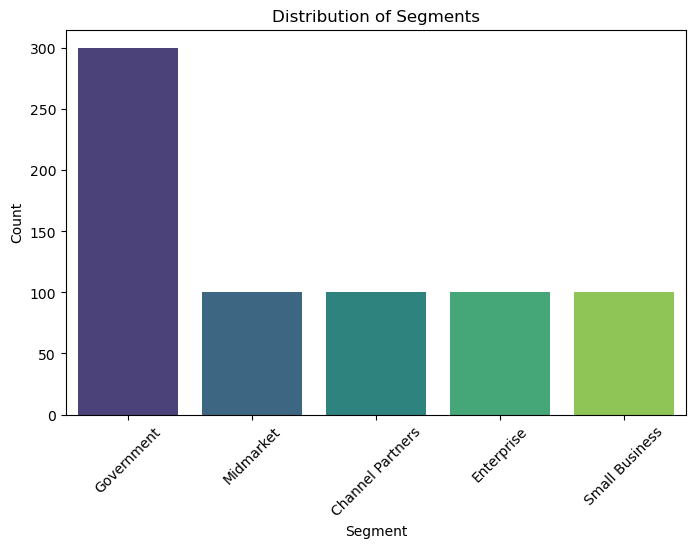

In [17]:
# Count occurrences of each unique segment

segment_counts = df["Segment"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="viridis")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.title("Distribution of Segments")
plt.xticks(rotation=45)  
plt.show()

Q-2. 
What are the most common countries represented in the dataset?

In [19]:
# Count occurrences of each country
country_counts = df["Country"].value_counts()
country_counts.head()

Country
Canada                      140
Germany                     140
France                      140
Mexico                      140
United States of America    140
Name: count, dtype: int64

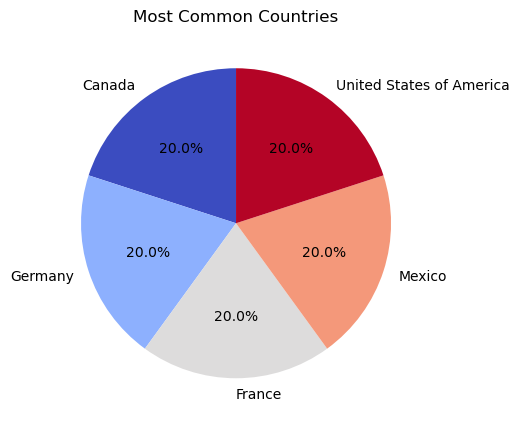

In [20]:
plt.figure(figsize=(5, 8))
df["Country"].value_counts().head(10).plot.pie(autopct="%1.1f%%", cmap="coolwarm", startangle=90)

plt.title("Most Common Countries")
plt.ylabel("") 
plt.show()

Q-3.
What are the different product types available?

In [22]:
# Get unique product types

unique_products = df["Product"].unique()
print("Different product types available:")
print(unique_products)

Different product types available:
[' Carretera ' ' Montana ' ' Paseo ' ' Velo ' ' VTT ' ' Amarilla ']


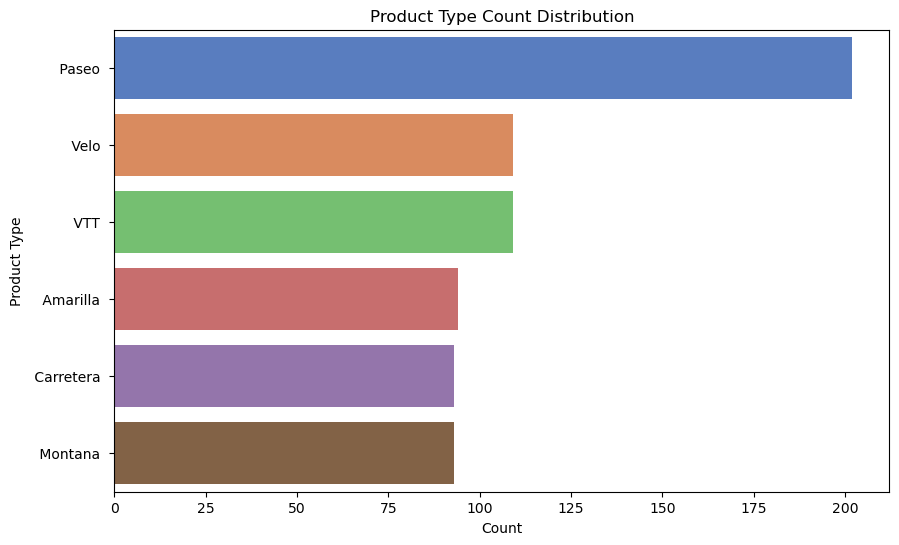

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Product", order=df["Product"].value_counts().index, palette="muted")

plt.xlabel("Count")
plt.ylabel("Product Type")
plt.title("Product Type Count Distribution")
plt.show()

                                             Sales & Profitability Analysis

Q-4.
What is the total revenue, total cost, and total profit across all transactions?

In [26]:
# Calculate total values

total_revenue = df["Sales"].sum()
total_cost = df["COGS"].sum()
total_profit = df["Profit"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Cost: ${total_cost:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

Total Revenue: $118,726,350.29
Total Cost: $101,832,648.00
Total Profit: $16,893,702.29


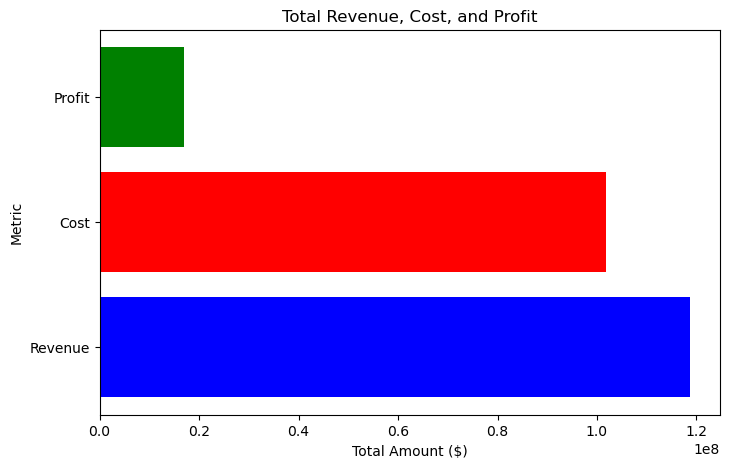

In [27]:
totals = {"Revenue": total_revenue, "Cost": total_cost, "Profit": total_profit}

plt.figure(figsize=(8, 5))
plt.barh(list(totals.keys()), list(totals.values()), color=["blue", "red", "green"])

plt.xlabel("Total Amount ($)")
plt.ylabel("Metric")
plt.title("Total Revenue, Cost, and Profit")
plt.show()

Q-5.
How does the profit margin vary across different products?

In [29]:
# Calculate Profit Margin
df["Profit Margin (%)"] = (df["Profit"] / df["Sales"]) * 100

# Group by Product and calculate average profit margin
profit_margin_by_product = df.groupby("Product")["Profit Margin (%)"].mean().sort_values(ascending=False)
profit_margin_by_product

Product
Carretera     29.523012
Amarilla      29.304270
Paseo         28.981201
Montana       27.505168
Velo          26.485845
VTT           26.376518
Name: Profit Margin (%), dtype: float64

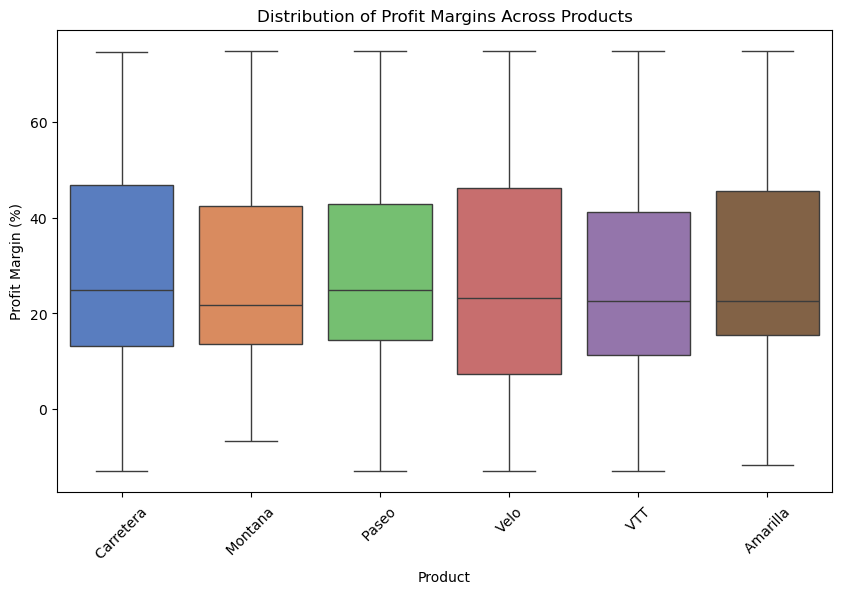

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Product", y="Profit Margin (%)", data=df, palette="muted")

# Add labels and title
plt.xlabel("Product")
plt.ylabel("Profit Margin (%)")
plt.title("Distribution of Profit Margins Across Products")
plt.xticks(rotation=45)
plt.show()

Q-6.
Which segment generates the highest revenue and profit?

In [32]:
# Group by Segment and calculate total revenue & profit

segment_revenue_profit = df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
segment_revenue_profit

,Sales,Profit
Segment,,
Government,52504260.68,11388173.18
Small Business,42427918.50,4143168.50
Enterprise,19611694.38,-614545.62
Midmarket,2381883.09,660103.09
Channel Partners,1800593.64,1316803.14


<Figure size 800x500 with 0 Axes>

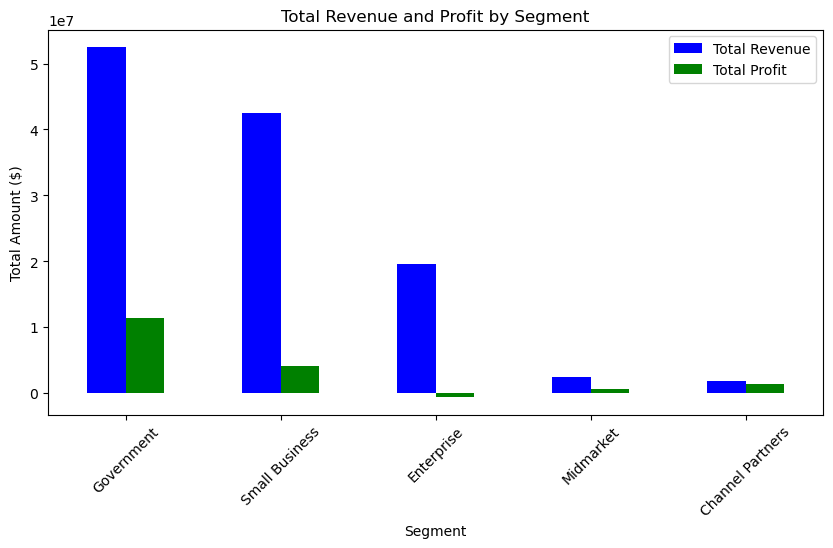

In [33]:
plt.figure(figsize=(8, 5))
segment_revenue_profit.plot(kind="bar", figsize=(10, 5), color=["blue", "green"])

plt.xlabel("Segment")
plt.ylabel("Total Amount ($)")
plt.title("Total Revenue and Profit by Segment")
plt.legend(["Total Revenue", "Total Profit"])
plt.xticks(rotation=45)
plt.show()

Q-7.
How do discounts impact profitability?

In [35]:
# Calculate Profit Margin (%)
df["Profit Margin (%)"] = (df["Profit"] / df["Sales"]) * 100

# Check correlation between Discounts and Profit Margin
discount_profit_corr = df[["Discounts", "Profit Margin (%)"]].corr()
discount_profit_corr

# Group data by discount levels and calculate the average profit margin
discount_impact = df.groupby("Discounts")["Profit Margin (%)"].mean().reset_index().sort_values(by="Discounts")
discount_impact

,Discounts,Profit Margin (%)
0,18.41,27.849928
1,25.34,27.849928
2,44.73,27.849928
3,48.15,32.659933
4,72.10,27.849928
...,...,...
509,112927.50,12.605042
510,115830.00,1.960784
511,119756.00,14.614122
512,125820.00,5.303030


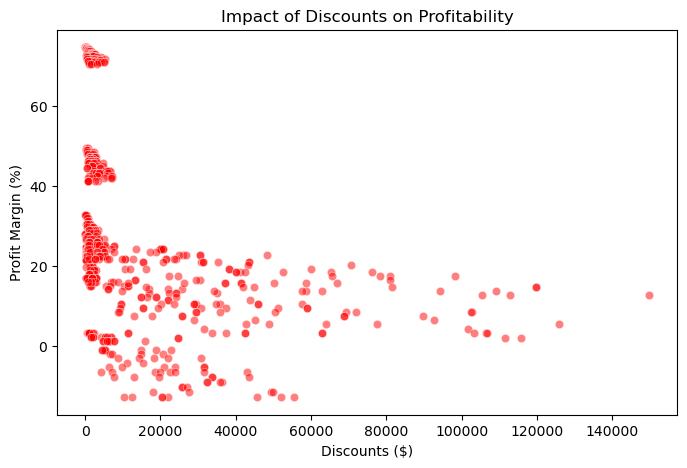

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Discounts"], y=df["Profit Margin (%)"], color="red", alpha=0.5)

plt.xlabel("Discounts ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Impact of Discounts on Profitability")
plt.show()

                                                         Time-Based Trends

Q-8. 
What is the trend of sales over time?

In [70]:
# Group sales data by Year-Month
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()

# Convert PeriodIndex to datetime for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

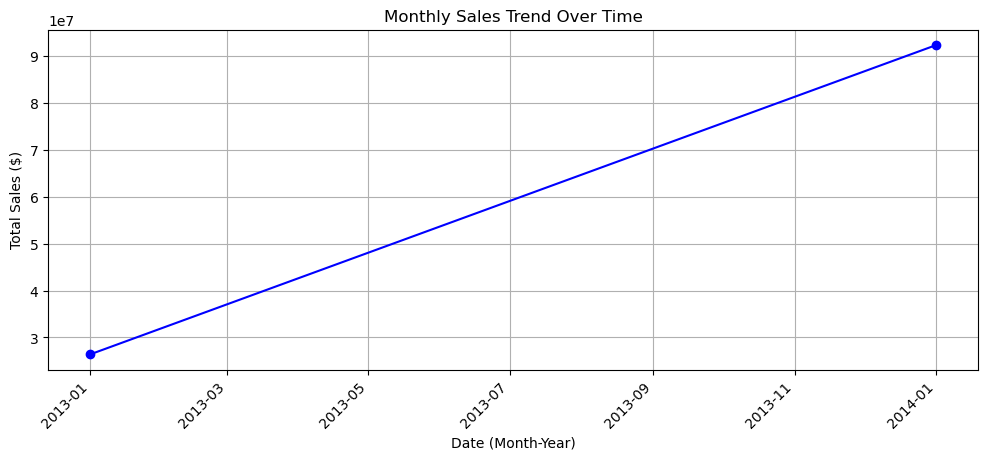

In [72]:
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o", color="blue")

plt.xlabel("Date (Month-Year)")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Q-9.
Are there seasonal trends in sales and profits?

In [60]:
# Group sales and profit by Season

seasonal_trends = df.groupby("Season")[["Sales", "Profit"]].sum().reindex(["Winter", "Spring", "Summer", "Autumn", "Dry Season", "Rainy Season"])
print(seasonal_trends)

                    Sales      Profit
Season                               
Winter        25059535.93  3773854.93
Spring        15671679.89  1929716.39
Summer        19270628.09  2616973.59
Autumn        37775154.27  5665634.27
Dry Season    10926021.38  1521254.38
Rainy Season  10023330.73  1386268.73


<Figure size 800x500 with 0 Axes>

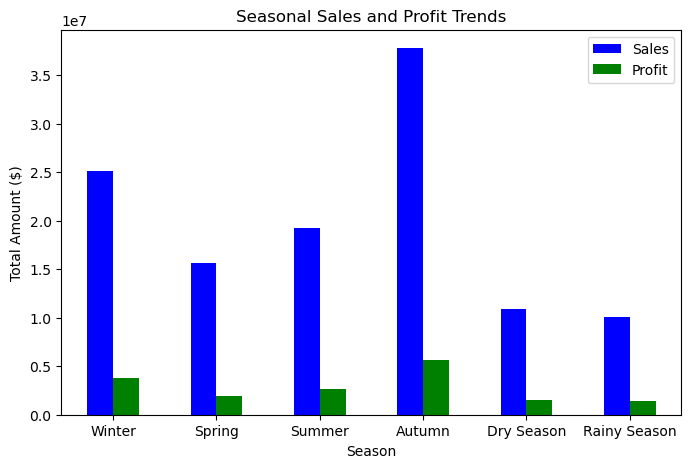

In [62]:
plt.figure(figsize=(8, 5))
seasonal_trends.plot(kind="bar", color=["blue", "green"], figsize=(8, 5))

plt.xlabel("Season")
plt.ylabel("Total Amount ($)")
plt.title("Seasonal Sales and Profit Trends")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

Q-10.
Which month had the highest and lowest sales?

In [74]:
# Group sales data by Month Name
monthly_sales = df.groupby("Month Name")["Sales"].sum()

# Sort months in the correct order
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
monthly_sales = monthly_sales.reindex(month_order)

# Find the highest and lowest sales months
highest_sales_month = monthly_sales.idxmax()
lowest_sales_month = monthly_sales.idxmin()

# Display results
print(f"😊 Highest Sales Month: {highest_sales_month} (${monthly_sales.max():,.2f})")
print(f"😒 Lowest Sales Month: {lowest_sales_month} (${monthly_sales.min():,.2f})")

😊 Highest Sales Month: October ($21,671,431.02)
😒 Lowest Sales Month: March ($5,586,859.87)


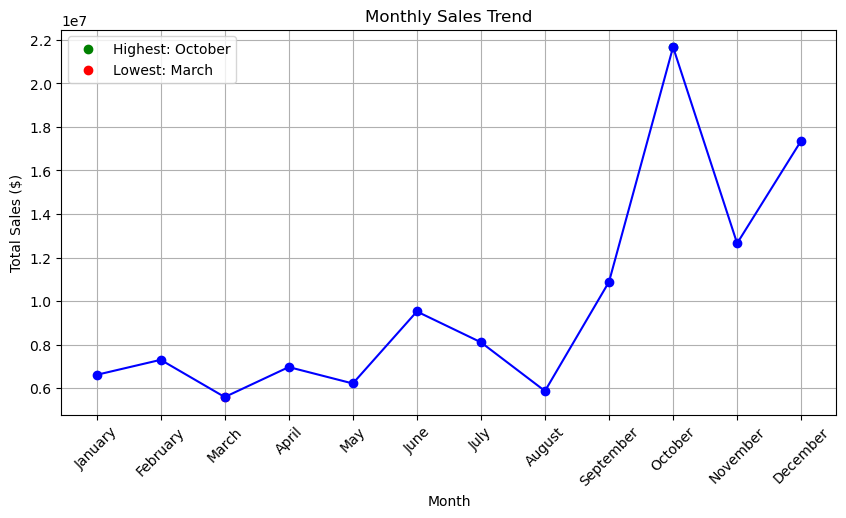

In [76]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", linestyle="-", color="blue")

# Highlight Highest & Lowest Months
plt.scatter(highest_sales_month, monthly_sales.max(), color="green", label=f"Highest: {highest_sales_month}")
plt.scatter(lowest_sales_month, monthly_sales.min(), color="red", label=f"Lowest: {lowest_sales_month}")

plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Q-11.
How do different years compare in terms of revenue and profit?

In [78]:
# Group sales and profit by year
yearly_trends = df.groupby("Year")[["Sales", "Profit"]].sum()

# Find the highest & lowest revenue years
highest_revenue_year = yearly_trends["Sales"].idxmax()
lowest_revenue_year = yearly_trends["Sales"].idxmin()

# Find the highest & lowest profit years
highest_profit_year = yearly_trends["Profit"].idxmax()
lowest_profit_year = yearly_trends["Profit"].idxmin()

# Display results
print(f"📈 Highest Revenue Year: {highest_revenue_year} (${yearly_trends['Sales'].max():,.2f})")
print(f"📉 Lowest Revenue Year: {lowest_revenue_year} (${yearly_trends['Sales'].min():,.2f})")
print(f"💰 Highest Profit Year: {highest_profit_year} (${yearly_trends['Profit'].max():,.2f})")
print(f"💸 Lowest Profit Year: {lowest_profit_year} (${yearly_trends['Profit'].min():,.2f})")

📈 Highest Revenue Year: 2014 ($92,311,094.78)
📉 Lowest Revenue Year: 2013 ($26,415,255.51)
💰 Highest Profit Year: 2014 ($13,015,237.78)
💸 Lowest Profit Year: 2013 ($3,878,464.51)


<Figure size 800x500 with 0 Axes>

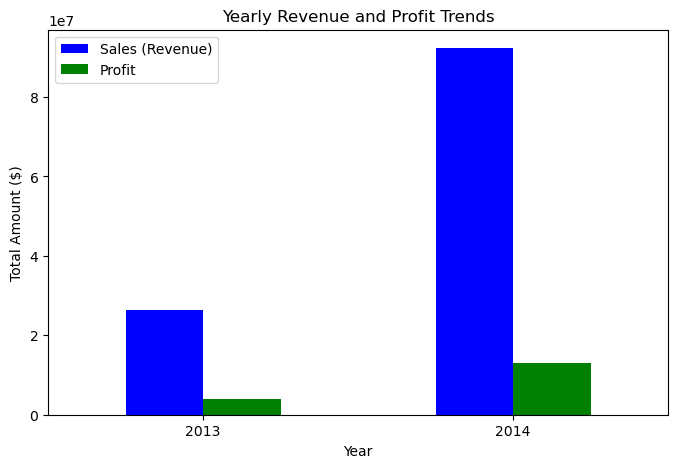

In [80]:
plt.figure(figsize=(8, 5))
yearly_trends.plot(kind="bar", color=["blue", "green"], figsize=(8, 5))

plt.xlabel("Year")
plt.ylabel("Total Amount ($)")
plt.title("Yearly Revenue and Profit Trends")
plt.xticks(rotation=0)
plt.legend(["Sales (Revenue)", "Profit"])
plt.show()

                                                   Geographic & Product Analysis

Q-12.
Which country has the highest sales and profits?

In [82]:
# Group sales and profit by Country
country_trends = df.groupby("Country")[["Sales", "Profit"]].sum()

# Find the country with the highest sales and profit
highest_sales_country = country_trends["Sales"].idxmax()
highest_profit_country = country_trends["Profit"].idxmax()

# Display results
print(f"📈 Country with Highest Sales: {highest_sales_country} (${country_trends['Sales'].max():,.2f})")
print(f"💰 Country with Highest Profit: {highest_profit_country} (${country_trends['Profit'].max():,.2f})")

📈 Country with Highest Sales: United States of America ($25,029,830.18)
💰 Country with Highest Profit: France ($3,781,020.79)


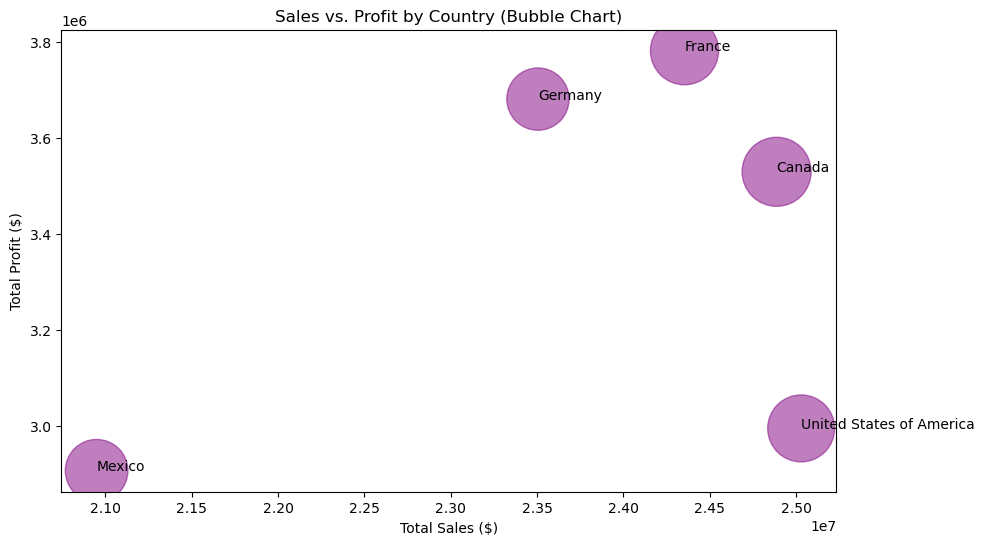

In [84]:
# Define bubble size based on total transactions (example: Units Sold)
bubble_size = df.groupby("Country")["Units Sold"].sum() / 100  # Adjust size for visibility

plt.figure(figsize=(10, 6))
plt.scatter(country_trends["Sales"], country_trends["Profit"], s=bubble_size, alpha=0.5, color="purple")

# Add labels for each country
for i, txt in enumerate(country_trends.index):
    plt.annotate(txt, (country_trends["Sales"].iloc[i], country_trends["Profit"].iloc[i]), fontsize=10)

# Add labels and title
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")
plt.title("Sales vs. Profit by Country (Bubble Chart)")
plt.show()

Q-13.
How do sales and profit vary by region?

In [86]:
# Check unique country names
print(df["Country"].unique())

['Canada' 'Germany' 'France' 'Mexico' 'United States of America']


In [88]:
# Define region mapping
region_mapping = {
    "Canada": "North America",
    "United States of America": "North America",
    "Mexico": "North America",
    "France": "Europe",
    "Germany": "Europe"
}

# Assign regions based on country
df["Region"] = df["Country"].map(region_mapping)

# Group by Region
region_trends = df.groupby("Region")[["Sales", "Profit"]].sum()
print(region_trends)

                     Sales      Profit
Region                                
Europe         47859513.11  7461409.61
North America  70866837.18  9432292.68


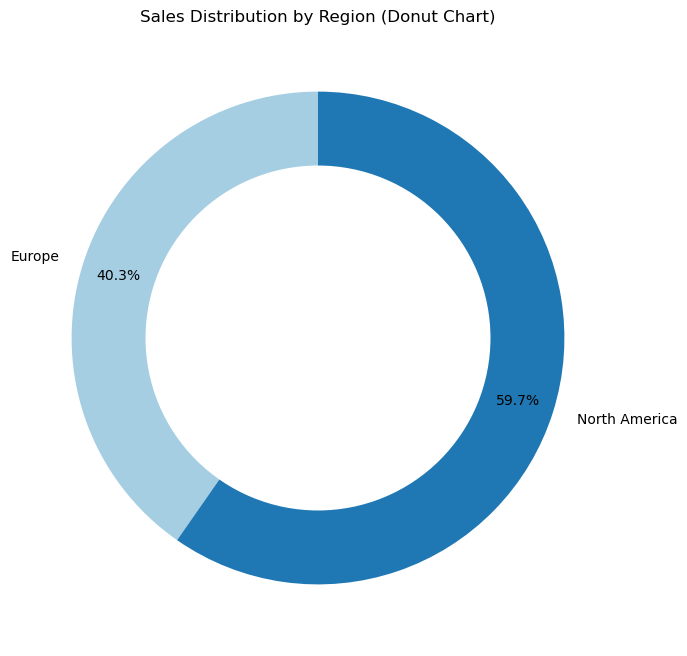

In [90]:
# Group by Region and calculate total Sales

region_sales = df.groupby("Region")["Sales"].sum()

colors = plt.cm.Paired.colors  
plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=region_sales.index, autopct="%1.1f%%", colors=colors, startangle=90, pctdistance=0.85)
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)
plt.title("Sales Distribution by Region (Donut Chart)")
plt.show()

Q-14. 
Which product category is the most profitable by region?

In [92]:
# Group by Product and calculate total Profit
product_profit = df.groupby("Product")["Profit"].sum().reset_index()

# Find the most and least profitable product categories
most_profitable_product = product_profit.loc[product_profit["Profit"].idxmax()]
least_profitable_product = product_profit.loc[product_profit["Profit"].idxmin()]

# Display results
print(f"💰 Most Profitable Product: {most_profitable_product['Product']} (${most_profitable_product['Profit']:,.2f})")
print(f"📉 Least Profitable Product: {least_profitable_product['Product']} (${least_profitable_product['Profit']:,.2f})")

💰 Most Profitable Product:  Paseo  ($4,797,437.96)
📉 Least Profitable Product:  Carretera  ($1,826,804.89)


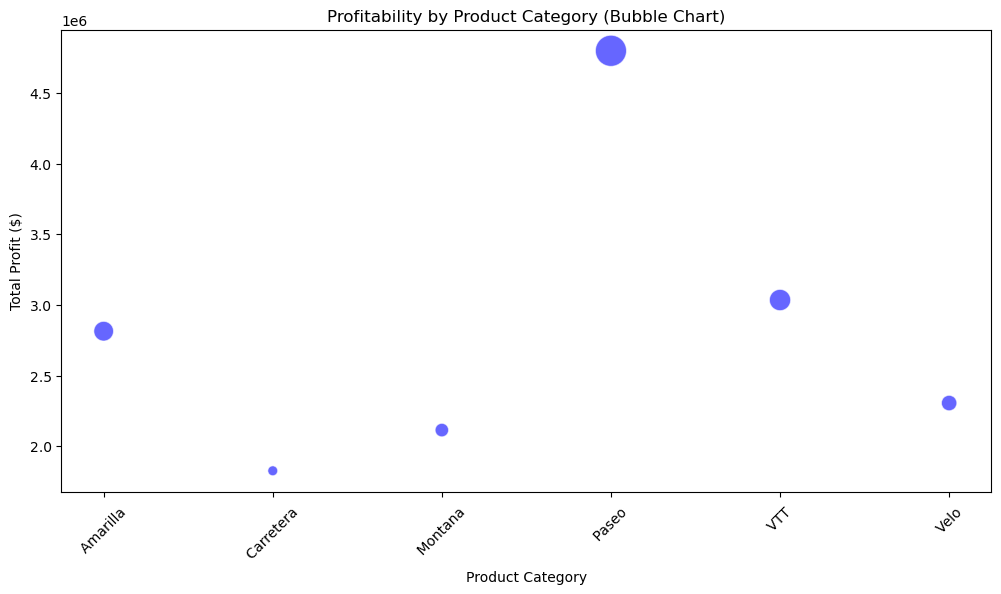

In [94]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=product_profit["Product"], 
    y=product_profit["Profit"], 
    size=product_profit["Profit"], 
    sizes=(50, 500), 
    alpha=0.6, 
    color="blue"
)

# Add labels and title
plt.xlabel("Product Category")
plt.ylabel("Total Profit ($)")
plt.title("Profitability by Product Category (Bubble Chart)")
plt.xticks(rotation=45)
plt.legend([],[], frameon=False)  # Hide legend for bubble size
plt.show()

Q-15. 
Are there certain products that perform better in specific countries?

In [96]:
# Group data by Product and Country, summing up Sales and Profit
product_country_performance = df.groupby(["Country", "Product"])[["Sales", "Profit"]].sum().reset_index()

# Sort by Country and Profit to see the top-performing products per country
product_country_performance = product_country_performance.sort_values(by=["Country", "Profit"], ascending=[True, False])

# Display first few rows
print(product_country_performance.head(10))

   Country      Product       Sales      Profit
3   Canada       Paseo   7611520.99  1265017.99
0   Canada    Amarilla   3855765.88   646861.38
4   Canada         VTT   4768754.31   488808.81
1   Canada   Carretera   2610204.34   436105.34
5   Canada        Velo   3329490.34   370568.34
2   Canada     Montana   2711919.03   321867.03
9   France       Paseo   5597751.06   838748.56
10  France         VTT   3811193.59   716371.09
11  France        Velo   3978096.24   707930.24
6   France    Amarilla   4016427.13   667867.63


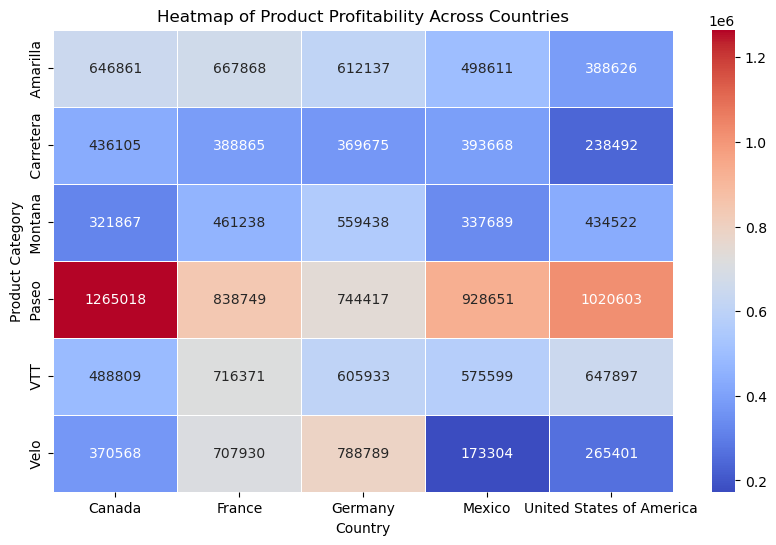

In [98]:
# Pivot table for heatmap
heatmap_data = product_country_performance.pivot(index="Product", columns="Country", values="Profit")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="coolwarm", linewidths=0.5)
plt.xlabel("Country")
plt.ylabel("Product Category")
plt.title("Heatmap of Product Profitability Across Countries")
plt.show()

                                                    Pricing & Discount Analysis

Q-16. 
What is the average sale price per product?

In [102]:
# Calculate the average sale price per product

avg_sale_price = df.groupby("Product")["Sale Price"].mean().reset_index()
avg_sale_price

,Product,Sale Price
0,Amarilla,128.680851
1,Carretera,111.774194
2,Montana,117.096774
3,Paseo,108.178218
4,VTT,138.587156
5,Velo,115.238532


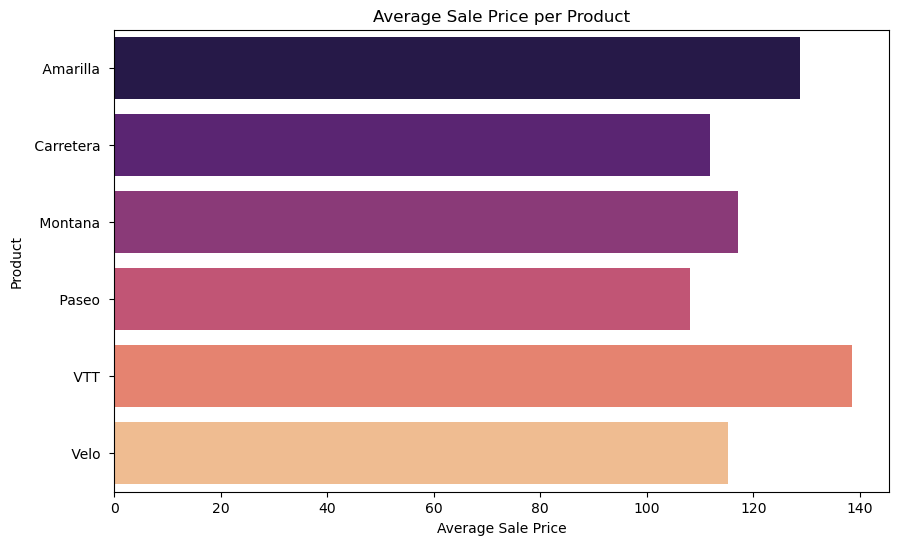

In [112]:
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_sale_price, y="Product", x="Sale Price", palette="magma")
plt.xlabel("Average Sale Price")
plt.ylabel("Product")
plt.title("Average Sale Price per Product")
plt.show()

Q-17. 
How do different discount bands impact sales?

In [116]:
# Group by Discount Band and sum Sales

discount_impact = df.groupby("Discount Band")["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False)
discount_impact

,Discount Band,Sales
2,Medium,38780430.84
0,High,37372486.74
1,Low,34629778.71
3,None,7943654.00


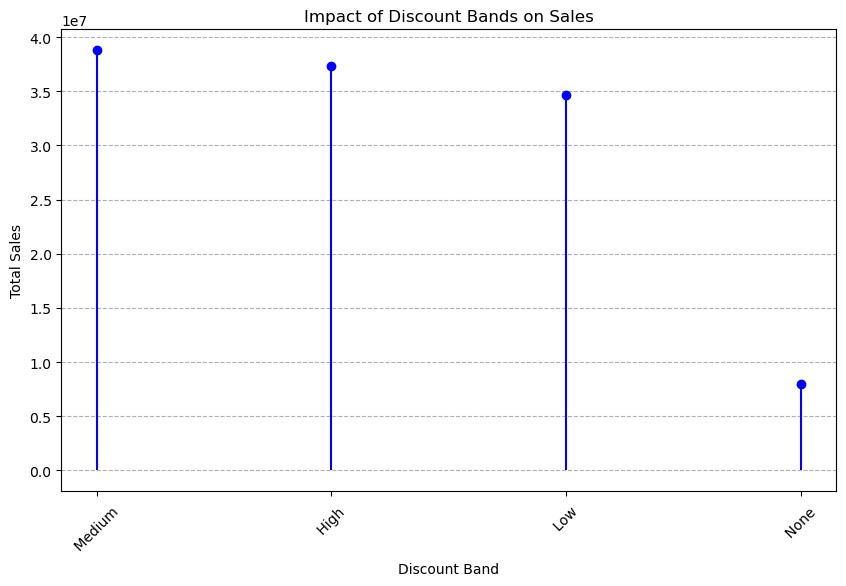

In [134]:
# Create Lollipop Chart
plt.figure(figsize=(10, 6))
plt.stem(discount_impact["Discount Band"], discount_impact["Sales"], basefmt=" ", linefmt="b-", markerfmt="bo")

# Labels and title
plt.xlabel("Discount Band")
plt.ylabel("Total Sales")
plt.title("Impact of Discount Bands on Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=1)
plt.show()

Q-18.
Is there a correlation between discounts and units sold?

In [136]:
# Check correlation between Discounts and Units Sold
correlation = df["Discounts"].corr(df["Units Sold"])
print(f"Correlation between Discounts and Units Sold: {correlation:.2f}")

Correlation between Discounts and Units Sold: 0.27


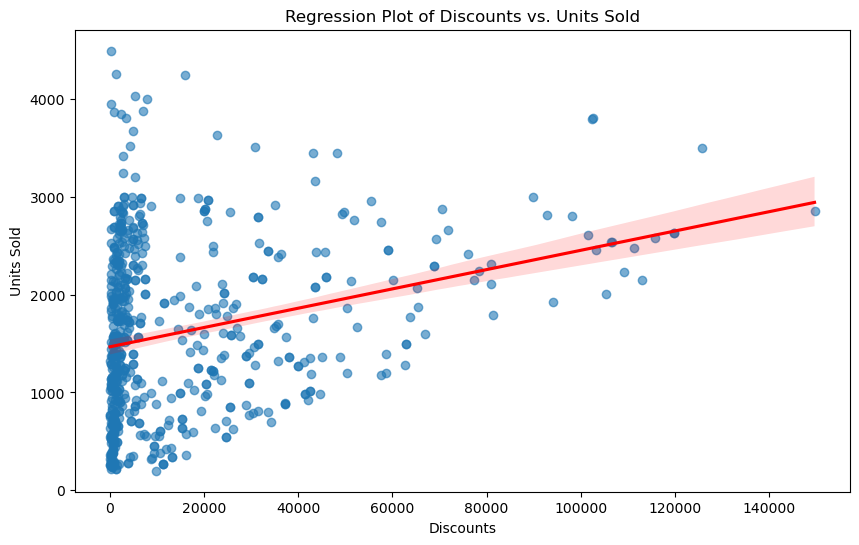

In [154]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="Discounts", y="Units Sold", scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.xlabel("Discounts")
plt.ylabel("Units Sold")
plt.title("Regression Plot of Discounts vs. Units Sold")
plt.show()

                                                              Cost Analysis

In [ ]:
Q-19.
What is the average cost of goods sold (COGS) per product?

In [158]:
# Calculate the average COGS per product
avg_cogs = df.groupby("Product")["COGS"].mean().reset_index()
avg_cogs

,Product,COGS
0,Amarilla,158861.829787
1,Carretera,128908.634409
2,Montana,142753.193548
3,Paseo,139671.811881
4,VTT,160342.321101
5,Velo,146275.844037


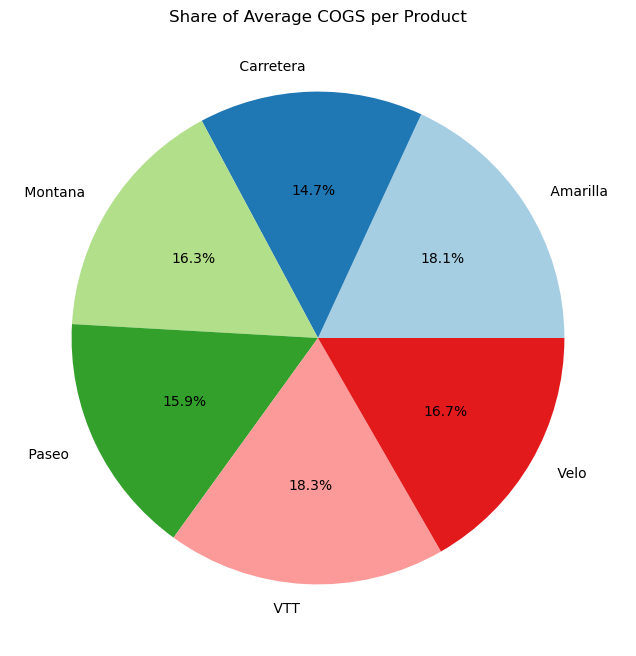

In [166]:
plt.figure(figsize=(8, 8))
plt.pie(avg_cogs["COGS"], labels=avg_cogs["Product"], autopct="%1.1f%%", colors=plt.cm.Paired.colors)
plt.title("Share of Average COGS per Product")
plt.show()

Q-20.
How does the cost-to-sales ratio vary across segments?

In [170]:
# Create a new column for Cost-to-Sales Ratio
df["Cost-to-Sales Ratio"] = df["COGS"] / df["Sales"]

# Group by Segment and calculate the average Cost-to-Sales Ratio
segment_ratio = df.groupby("Segment")["Cost-to-Sales Ratio"].mean().reset_index()
segment_ratio

,Segment,Cost-to-Sales Ratio
0,Channel Partners,0.269769
1,Enterprise,1.030563
2,Government,0.706686
3,Midmarket,0.723254
4,Small Business,0.903290


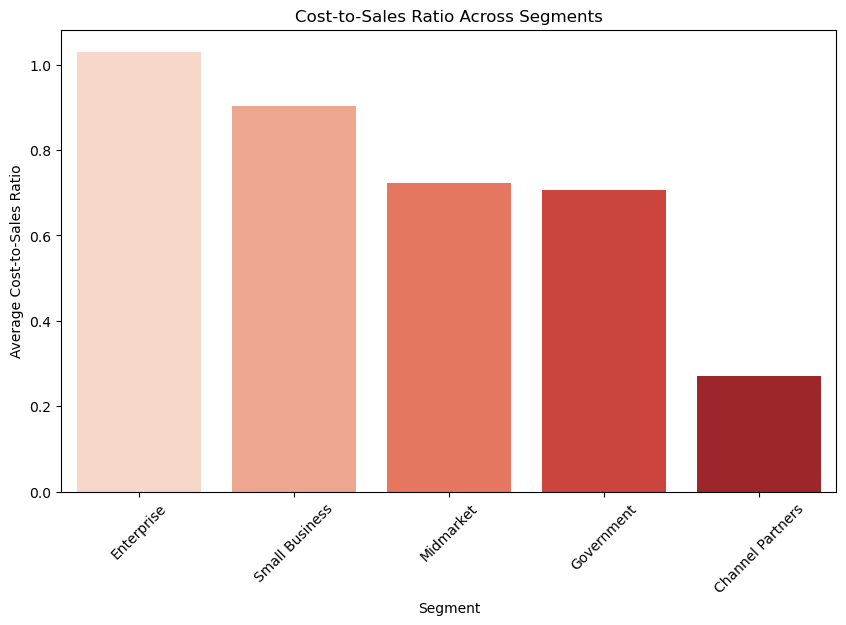

In [188]:
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_ratio, x="Segment", y="Cost-to-Sales Ratio", palette="Reds")
plt.xlabel("Segment")
plt.ylabel("Average Cost-to-Sales Ratio")
plt.title("Cost-to-Sales Ratio Across Segments")
plt.xticks(rotation=45)
plt.show()